In [ ]:
# загрузка библиотек
# методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# Для работы с файлами
import os

# импортируем модуль для загрузки данных
import gdown

# для разделения выборок
from sklearn.model_selection import train_test_split

# для создания сети
from tensorflow.keras.models import Sequential

# для создания слоев
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

# для работы с изображениями
from tensorflow.keras.preprocessing import image

# оптимизатор
from tensorflow.keras.optimizers import Adam

# модуль для отсчета времени
import time

In [ ]:
# загрузка датасета
from google.colab import files
uploaded = files.upload()

Saving pref.zip to pref.zip


In [ ]:
# распаковка архива
import zipfile
with zipfile.ZipFile('pref.zip', 'r') as zip_ref:
       zip_ref.extractall('/content/')

In [ ]:
# задание пути
IMAGE_PATH = '/content/pref/'

In [ ]:
# Получение списка папок, находящемуся по адресу в скобках
os.listdir(IMAGE_PATH)

['vozd_puz', 'prigar']

In [ ]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 2, метки классов: ['prigar', 'vozd_puz']


In [ ]:
# Получения списка файлов для каждого класса

for cls in CLASS_LIST:
    print(cls, ':', os.listdir(f'{IMAGE_PATH}{cls}/'))

prigar : ['HT-SUA501GC-T1V-C-Snapshot-20250823-134323-209-449661302442.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134545-995-451089159351.BMP', 'aug_0_3531.bmp', 'aug_0_3528.bmp', 'aug_0_1648.bmp', 'aug_0_4359.bmp', 'aug_0_151.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134610-473-451333944864.BMP', 'aug_0_2949.bmp', 'aug_0_3857.bmp', 'aug_0_3473.bmp', 'aug_0_5506.bmp', 'aug_0_6447.bmp', 'aug_0_623.bmp', 'aug_0_9523.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134618-248-451411695026.BMP', 'aug_0_8539.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134358-511-450014321214.BMP', 'aug_0_3600.bmp', 'aug_0_2334.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134633-995-451569166197.BMP', 'aug_0_7350.bmp', 'aug_0_11.bmp', 'aug_0_9556.bmp', 'aug_0_4417.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134408-062-450109835907.BMP', 'aug_0_3358.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134430-160-450330813600.BMP', 'HT-SUA501GC-T1V-C-Snapshot-20250823-134417-979-450208998745.BMP', 'aug_0_9532.bmp', 'aug_0_4409.b

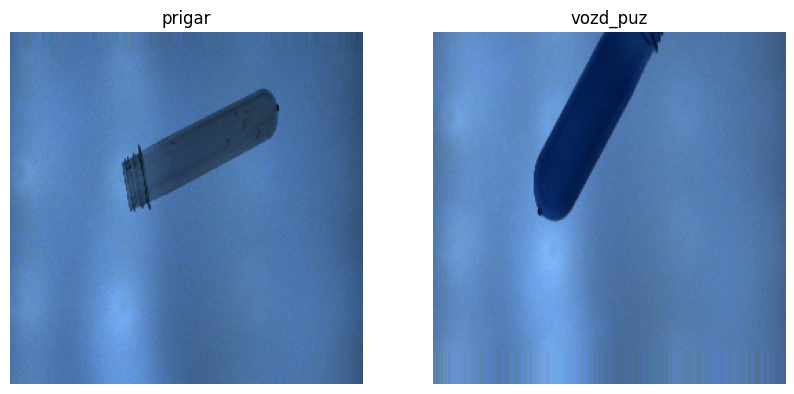

In [ ]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(10, 5))

# Для всех номеров классов:
for i in range(CLASS_COUNT):

    # Формирование пути к папке содержимого класса
    car_path = f'{IMAGE_PATH}{CLASS_LIST[i]}/'

    # Выбор случайного фото из i-го класса
    img_path = car_path + random.choice(os.listdir(car_path))

    # Отображение фотографии (подробнее будет объяснено далее)
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')

# Отрисовка всего полотна
plt.show()

In [ ]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов, соответствующих файлам

for class_label in range(CLASS_COUNT):    # Для всех классов по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Формирование полного пути к папке с изображениями класса
    class_files = os.listdir(class_path)  # Получение списка имен файлов с изображениями текущего класса
    print(f'Размер класса {class_name} составляет {len(class_files)} фото')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print()
print('Общий размер базы для обучения:', len(data_labels))

Размер класса prigar составляет 553 фото
Размер класса vozd_puz составляет 621 фото

Общий размер базы для обучения: 1174


In [ ]:
# Задание единых размеров изображений
IMG_WIDTH = 128                           # Ширина изображения
IMG_HEIGHT = 64                           # Высота изображения

In [ ]:
# перевод изображений в тензоры
data_images = []                          # Пустой список для данных изображений

for file_name in data_files:
    # Открытие и смена размера изображения
    img = Image.open(file_name).resize((IMG_WIDTH, IMG_HEIGHT))
    img_np = np.array(img)                # Перевод в numpy-массив
    data_images.append(img_np)            # Добавление изображения в виде numpy-массива к общему списку

x_data = np.array(data_images)            # Перевод общего списка изображений в numpy-массив
y_data = np.array(data_labels)            # Перевод общего списка меток класса в numpy-массив

print(f'В массив собрано {len(data_images)} фотографий следующей формы: {img_np.shape}')
print(f'Общий массив данных изображений следующей формы: {x_data.shape}')
print(f'Общий массив меток классов следующей формы: {y_data.shape}')

В массив собрано 1174 фотографий следующей формы: (64, 128, 3)
Общий массив данных изображений следующей формы: (1174, 64, 128, 3)
Общий массив меток классов следующей формы: (1174,)


array([[[ 77, 111, 155],
        [ 80, 115, 160],
        [ 83, 119, 165],
        ...,
        [ 60,  87, 122],
        [ 58,  86, 118],
        [ 57,  85, 117]],

       [[ 77, 112, 154],
        [ 80, 116, 159],
        [ 83, 120, 166],
        ...,
        [ 60,  89, 122],
        [ 59,  87, 120],
        [ 58,  86, 119]],

       [[ 78, 113, 155],
        [ 82, 116, 159],
        [ 84, 121, 166],
        ...,
        [ 60,  89, 124],
        [ 59,  88, 123],
        [ 59,  86, 121]],

       ...,

       [[ 85, 122, 168],
        [ 88, 125, 172],
        [ 89, 127, 175],
        ...,
        [ 68,  98, 135],
        [ 66,  96, 134],
        [ 65,  95, 132]],

       [[ 87, 124, 171],
        [ 87, 126, 172],
        [ 89, 128, 175],
        ...,
        [ 68,  99, 137],
        [ 67,  97, 135],
        [ 65,  95, 131]],

       [[ 88, 125, 173],
        [ 88, 127, 178],
        [ 90, 129, 178],
        ...,
        [ 69, 100, 139],
        [ 67,  98, 137],
        [ 66,  95, 133]]], dtype=uint8)
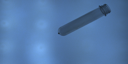

In [ ]:
# вывод первого изображения (трехмерный тензор)
x_data[0]

In [ ]:
# Создание модели последовательной архитектуры
model = Sequential()

In [ ]:
# Первый сверточный блок
model.add(Conv2D(32, (3, 3), name='First_C', padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))  # (64,128,3) --> (64,128,32) меняется кол-во фильтров
model.add(BatchNormalization(name='First_B'))   # (64,128,32) --> (64,128,32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Второй сверточный блок
model.add(Conv2D(32, (3, 3), name='Second_C', padding='same', activation='relu'))  # (64,128,32) --> (64,128,32) нет изменений
model.add(MaxPooling2D(pool_size=(2, 2), name='Second_M'))  # сжимает размер в два раза, глубина не изм. (64,128,32) --> (32,64,32)

In [ ]:
# Третий сверточный блок
model.add(Conv2D(32, (3, 3), name='Third_C', padding='same', activation='relu'))  # (32,64,32) --> (32,64,32) нет изменений
model.add(BatchNormalization(name='Third_B'))  # (32,64,32) --> (32,64,32) нет изменений
model.add(Dropout(0.2, name='Third_D'))  # (32,64,32) --> (32,64,32) нет изменений

In [ ]:
# Четвертый сверточный блок
model.add(Conv2D(32, (3, 3), name='Fourth_F_Unique', padding='same', activation='relu'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(MaxPooling2D(pool_size=(2, 2), name='Fourth_M_Unique'))  # сжимает размер в два раза, хотя padding='valid', потерь нет, т.к. делится кратно, глубина не изм.(32,64,32) --> (32,64,32)
model.add(Dropout(0.2, name='Fourth_D_Unique'))  # (32,64,32) --> (32,64,32) нет изменений

In [ ]:
# Пятый сверточный блок
model.add(Conv2D(64, (3, 3), name='Fifth_D', padding='same', activation='relu'))  # (16,32,32) --> (16,32,64) меняется количество фильтров
model.add(BatchNormalization(name='Fifth_B'))  # (7,14,512) --> (16,32,64) --> (16,32,64)


In [ ]:
# Блок классификации
model.add(Flatten(name='Class_11'))  # слой преобразования многомерных данных в одномерные (16,32,64) --> (16*32*64) --> (32768)
model.add(Dense(128, activation='relu', name='Class_12'))  # полносвязный слой, меняется кол-во нейронов (32768) --> (128)
model.add(Dense(CLASS_COUNT, activation='softmax', name='Class_13'))  # выходной полносвязный слой, кол-во нейронов = количество классов (128) --> (2)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ First_C (Conv2D)                │ (None, 64, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ First_B (BatchNormalization)    │ (None, 64, 128, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Second_C (Conv2D)               │ (None, 64, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Second_M (MaxPooling2D)         │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_C (Conv2D)                │ (None, 32, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_B (BatchNormalization)    │ (None, 32, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_D (Dropout)               │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_F_Unique (Conv2D)        │ (None, 32, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_M_Unique (MaxPooling2D)  │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_D_Unique (Dropout)       │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fifth_D (Conv2D)                │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fifth_B (BatchNormalization)    │ (None, 16, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_11 (Flatten)              │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_12 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,242,338 (16.18 MB)

 Trainable params: 4,242,082 (16.18 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Компиляция модели
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

In [ ]:
# Разделение данных на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [ ]:
# Определение колбэков
model_checkpoint = ModelCheckpoint(filepath='model_best.h5', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=2, verbose=1)

In [ ]:
# Обучение модели и сохранение истории
history = model.fit(x_train,  # Обучающая выборка
                    y_train,  # Метки обучающей выборки
                    validation_data=(x_test, y_test),  # Тестовая выборка для валидации
                    shuffle=True,
                    batch_size=16,
                    epochs=30,
                    verbose=1,
                    callbacks=[model_checkpoint, reduce_lr])  # Добавление колбэков

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7919 - loss: 0.6720
Epoch 1: val_loss improved from inf to 2.21637, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.7938 - loss: 0.6655 - val_accuracy: 0.5191 - val_loss: 2.2164 - learning_rate: 1.0000e-04
Epoch 2/30
54/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0114
Epoch 2: val_loss improved from 2.21637 to 0.30133, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9981 - loss: 0.0110 - val_accuracy: 0.8255 - val_loss: 0.3013 - learning_rate: 1.0000e-04
Epoch 3/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9987 - loss: 0.0028
Epoch 3: val_loss did not improve from 0.30133
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9987 - loss: 0.0029 - val_accuracy: 0.5362 - val_loss: 1.5565 - learning_rate: 1.0000e-04
Epoch 4/30
54/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 4: val_loss did not improve from 0.30133

Epoch 4: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.4851 - val_loss: 2.2336 - learning_rate: 1.0000e-04
Epoch 5/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 4.9300e-04
Epoch 5: val_loss did not improve from 0.30133
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 5.0576e-04 - val_accuracy: 

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 3.1822e-04 - val_accuracy: 0.9106 - val_loss: 0.2398 - learning_rate: 2.1600e-05
Epoch 10/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 2.1923e-04
Epoch 10: val_loss improved from 0.23982 to 0.18126, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 2.2413e-04 - val_accuracy: 0.9362 - val_loss: 0.1813 - learning_rate: 2.1600e-05
Epoch 11/30
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 3.1035e-04
Epoch 11: val_loss improved from 0.18126 to 0.15454, saving model to model_best.h5


...

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 2.6321e-04 - val_accuracy: 0.9489 - val_loss: 0.1303 - learning_rate: 2.1600e-05
Epoch 13/30
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 2.1487e-04
Epoch 13: val_loss improved from 0.13026 to 0.11053, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 2.1639e-04 - val_accuracy: 0.9532 - val_loss: 0.1105 - learning_rate: 2.1600e-05
Epoch 14/30
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 3.4120e-04
Epoch 14: val_loss improved from 0.11053 to 0.10376, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 3.3883e-04 - val_accuracy: 0.9532 - val_loss: 0.1038 - learning_rate: 2.1600e-05
Epoch 15/30
54/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.6834e-04 
Epoch 15: val_loss improved from 0.10376 to 0.09200, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 1.6992e-04 - val_accuracy: 0.9574 - val_loss: 0.0920 - learning_rate: 2.1600e-05
Epoch 16/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.8812e-04
Epoch 16: val_loss did not improve from 0.09200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 1.8533e-04 - val_accuracy: 0.9574 - val_loss: 0.0925 - learning_rate: 2.1600e-05
Epoch 17/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 2.0376e-04
Epoch 17: val_loss did not improve from 0.09200

Epoch 17: ReduceLROnPlateau reducing learning rate to 1.2959999367012642e-05.
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 1.9926e-04 - val_accuracy: 0.9532 - val_loss: 0.0955 - learning_rate: 2.1600e-05
Epoch 18/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 5.3668e-04
Epoch 18: val_loss improved from 0.09200 to 0.07924, saving model to model_best.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 5.3485e-04 - val_accuracy: 0.9702 - val_loss: 0.0792 - learning_rate: 1.2960e-05
Epoch 19/30
54/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.1517e-04
Epoch 19: val_loss did not improve from 0.07924
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 1.1877e-04 - val_accuracy: 0.9702 - val_loss: 0.0812 - learning_rate: 1.2960e-05
Epoch 20/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.4011e-04
Epoch 20: val_loss did not improve from 0.07924

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.775999620207585e-06.
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 1.3936e-04 - val_accuracy: 0.9617 - val_loss: 0.0854 - learning_rate: 1.2960e-05
Epoch 21/30
55/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.3843e-04
Epoch 21: val_loss did not improve from 0.07924
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 

In [ ]:
scores = model.evaluate(x_data,
                        y_data,
                        verbose=1
                        )
print('Процент верных ответов на тестовых данных:', round(scores[1],2) * 100, '%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9926 - loss: 0.0186
Процент верных ответов на тестовых данных: 98.0 %


In [ ]:
# Оценка модели на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f'Тестовая точность: {test_accuracy:.4f}')
print(f'Тестовая потеря: {test_loss:.4f}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9431 - loss: 0.1387 
Тестовая точность: 0.9574
Тестовая потеря: 0.1004


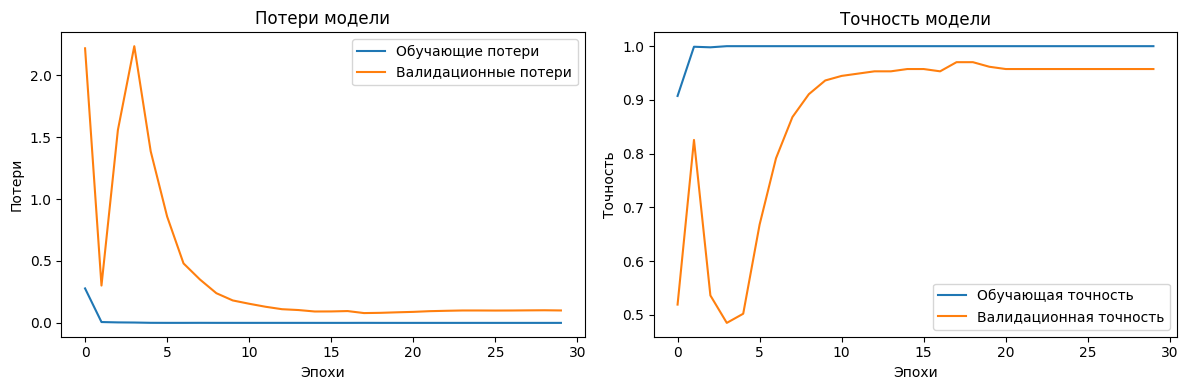

In [ ]:
# Визуализация процесса обучения
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Обучающие потери')
plt.plot(history.history['val_loss'], label='Валидационные потери')
plt.title('Потери модели')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Обучающая точность')
plt.plot(history.history['val_accuracy'], label='Валидационная точность')
plt.title('Точность модели')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Получение предсказаний
predictions = model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


In [ ]:
# Определение класса с максимальной вероятностью для каждого изображения
predicted_classes = np.argmax(predictions, axis=1)

In [ ]:
# Выбор одного изображения из каждого класса
unique_classes = np.unique(predicted_classes)
images_per_class = []
for cls in unique_classes:
    class_indices = np.where(predicted_classes == cls)[0]
    if len(class_indices) > 0:
        images_per_class.append(x_test[class_indices[0]])

In [ ]:
# После завершения обучения модели
model.save('my_model.keras')